# MINLP-Search — results explorer

**What this notebook is.** An interactive companion to the experiment framework. It explains what
was built, shows what has been verified, and renders every result as a figure you can export for an
article. Nothing here recomputes experiments — it reads the results that the studies already wrote
to disk.

**How to use it.** Run all cells top to bottom, then drive the widgets. Every section starts with a
short explanation of what you are looking at and why it matters.

**Contents**

| section | question it answers |
|---|---|
| 0. The problem | what is being tested, and what counts as a good answer |
| 0.3 Testing methodology | how a study is specified, executed, scored and analysed |
| 1. Priorities | what a "priority" is, what they look like, and how much of the data they allow |
| 2. What has been run | which studies exist, what they contain, and whether they are complete |
| 3. Badania I | are the hyperparameters justified, and what does more quality cost |
| 4. Badania II | what affects the method (data size, noise, feature type, strictness …) |
| 5. Badania III | how does it compare with established counterfactual methods |
| 6. Figure export | save any figure for the article |
| 7. Extending | how to add a new study, metric, dataset or priority set |


In [1]:
import sys, json, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")
logging.disable(logging.INFO)          # the library logs each search stage at INFO

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "explainit").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp._context import load_context
from explainit.experiments.continuous_minlp.priority_sets import PRIORITY_SETS, build_priorities
from explainit.experiments.continuous_minlp.priority_methods.methods import (
    compute_priority_score, max_attainable_priority,
)
from explainit.experiments.paper.common.registry import (
    RESULTS_ROOT, RunRegistry, current_run_ids,
)
from explainit.experiments.paper.common.runspec import expand_grid, load_study_config
from explainit.experiments.paper.common import stats

PAPER_DIR = PROJECT_ROOT / "explainit" / "experiments" / "paper"
FIGURES_DIR = PAPER_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.autolayout": True})
pd.set_option("display.width", 200)

_CTX, _STUDY = {}, {}

def ctx(dataset):
    """Dataset + trained model, cached."""
    if dataset not in _CTX:
        _CTX[dataset] = load_context(dataset)
    return _CTX[dataset]

def study(name, stale=False):
    """Per-counterfactual rows of a study, restricted to the current config."""
    key = (name, stale)
    if key not in _STUDY:
        reg = RunRegistry(name)
        ids = None if stale else current_run_ids(name)
        _STUDY[key] = reg.load_counterfactuals(run_ids=ids)
    return _STUDY[key]

def available_studies():
    return sorted(p.name for p in RESULTS_ROOT.glob("*") if (p / "index.csv").exists())

def base_datasets():
    """Datasets with a priority set and a trained model, excluding factor variants."""
    out = []
    for key in sorted(PRIORITY_SETS):
        if "__" in key:
            continue
        if (PROJECT_ROOT / "explainit/experiments/continuous_minlp/models" / key / "model.keras").exists():
            out.append(key)
    return out

def save_fig(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"saved {path}")
    return path

print("datasets with priorities:", base_datasets())
print("studies on disk:", available_studies())

datasets with priorities: ['auto_mpg', 'bike_sharing_hourly', 'brazilian_houses_to_rent', 'carseats', 'diabetes', 'diamonds', 'insurance_charges']
studies on disk: ['method_diagnosis', 'smoke', 'step2_validation', 'study1_hyperparams', 'study2_factors', 'study3_comparison']


## 0. The problem being tested

We have a trained regression model and one instance — say a car whose predicted fuel consumption is
0.62 on a normalised scale. We want a **counterfactual**: a modified instance whose prediction hits a
requested **target** (say 0.43) within a tolerance `ε = 0.05`.

What makes this project different from classical counterfactual search is the second objective.
Every feature carries a user-declared **priority function** — a curve saying how acceptable each
value is *for this user*. The method must hit the target **and** maximise the sum of those
priorities, called the **priority score**.

So each attempt is judged on three things:

| | meaning |
|---|---|
| **validity** | did the counterfactual actually reach the target band |
| **normalised priority** | priority achieved ÷ best priority attainable in the allowed region — the main quality metric, comparable across datasets |
| **model rows** | how many instances the method sent to the model — the main cost metric, hardware independent |

Everything in this notebook is expressed in those three terms.

## 0.1 Reading guide — values, columns and statistics

This is a glossary for the short labels in the widgets, plots and tables. A **counterfactual (CF)**
is one proposed modified instance. An **attempt** is one method trying to make one CF for one
sample and seed. A table may average many attempts; `avg_` means that average at the run level.

| label | plain-language meaning | how to read it |
|---|---|---|
| `prediction`, `target` | the model output of a CF and the requested output | targets and predictions are scaled to 0–1; lower is not inherently better |
| `epsilon` / `ε` | permitted absolute prediction error | `0.05` means the prediction must lie within 0.05 of the target |
| `validity` | whether `abs(prediction - target) <= epsilon` | 1 / `True` is valid; a validity mean is the fraction of attempts that succeeded |
| `priority_score` | sum of the per-feature desirability values | higher is better, but raw scores depend on the number and type of features |
| `priority_score_normalised` / `priority` | `priority_score` divided by the best score attainable in that instance's allowed region | the primary quality measure; 1.0 is the attainable optimum and higher is better |
| `model_rows` | total rows passed to the predictive model | main compute-cost measure; lower is cheaper; it is a count, not elapsed time |
| `time_seconds`, `time_s` | elapsed wall-clock time | secondary cost measure; it depends on hardware |
| `l1` | sum of absolute feature changes from the original instance | proximity measure; lower means a smaller overall edit |
| `l2` | Euclidean length of the feature-change vector | another proximity measure; lower is a smaller edit |
| `n_changed`, `sparsity_fraction` | number / fraction of logical features changed | lower means the CF changes fewer features; a one-hot group counts as one logical categorical feature |
| `n`, `n_samples`, `n_cfs`, `n_cfs_valid`, `n_valid` | number of rows, selected source instances, requested CFs per instance, valid CFs, and valid rows used for a quality average | do not compare a priority mean without also checking `n_valid` and validity |
| `error = budget_exceeded`, `budget_fail` | the method reached its model-evaluation cap before completing | a failure rate of 0.20 means 20% of attempts exceeded the budget |
| `cf_source` | where the returned CF came from | `optimiser` is a search result; `anchor` is the Stage 1 reference point; `peak_lock_in` means the post-processing sweep improved it |
| `exemplar_source` | how Stage 1 found the anchor | `dataset_priority_filtered` means a real eligible training row; `random_in_range` means a generated point because no suitable row was found |
| `warm_start_best_model_gap` | real-model target error at the LP warm start | compare it with `epsilon`; a gap above epsilon exposes an inaccurate local surrogate |

**How the inferential tables work.** `delta` or `delta_vs_ref` is **variant/method A minus the
baseline/reference** on the same instance, so a negative priority delta means A is worse. `n_pairs`
or `pairs` is the number of matched instance-and-seed comparisons. `wins` / `losses` count paired
instances where A had higher / lower priority. `ci_low` and `ci_high` are the 95% bootstrap confidence
interval for the mean delta. `wilcoxon_p` is the paired Wilcoxon signed-rank p-value; `p_holm` is that
p-value after Holm correction for multiple comparisons. `alpha` is the chosen significance threshold
(usually 0.05). `cliffs_delta` is an effect size from −1 to +1: sign gives direction and magnitude
(`negligible`, `small`, `medium`, `large`) gives practical size. Statistical significance is evidence
about a difference, not proof that it is large or scientifically important.

## 0.2 Reading guide — settings, studies and encoded names

**Common run settings.** `seed` is the random-number seed; seeds 0, 1 and 2 repeat the same cell
under different controlled randomness. `n_samples` is the number of original test instances selected
for an arm. `n_cfs` is the number of requested alternatives per original instance (1 here).
`target_offset_pred_std = -1.0` asks for a prediction one model-output standard deviation lower than
the original; `-2.0` is the harder target. `target_offset` is the same idea in absolute normalised
prediction units. `skip_if_target_below` avoids impossible requests below the specified scale limit.

**MINLP-Search settings.** `shap_approx` selects sampled rather than exact Shapley values, and
`shap_num_samples` is the number of sampled Shapley permutations used to build the local surrogate
model. More samples usually make that surrogate more faithful, but they also increase `model_rows`,
which is the notebook's main compute-cost counter: the total number of rows / candidate points sent
through the predictive model while producing one counterfactual. It goes up because every extra
sampled permutation or refinement step asks the model to score more points. The arm called
`shap_budget` is simply the study's name for the experimental condition that **sweeps**
`shap_num_samples` across several values. Here an **arm** means one named experiment variant or
condition inside a study, not part of the algorithm itself; for example, one arm may use 50 Shapley
samples and another 200. A **sweep** means "systematically try a list of values for one setting and
compare the results". `max_iterations` is the maximum number of surrogate-rebuild/refinement cycles;
its sweep is called `refinement_passes`. `patience` stops those cycles after that many non-improving
iterations. `target_exemplar_epsilon` is how close an anchor may be to the target during Stage 1;
it is studied as `exemplar_tolerance`. `max_model_rows` is a per-instance evaluation cap, used for
fair budget arms.

`peak_lock_in` is Stage 7 post-processing: it tries moving features to their most preferred values while
compensating elsewhere to keep the prediction in the target band. `peak_lock_in_ablation` compares it
off versus on; `peak_lock_in_max_sweeps` limits repeated passes over features. `trust_region` with
`trust_region_init` restricts an update to a local radius so a linear surrogate is not used too far
from where it was built. `residual_correction` re-aims the next surrogate at the remaining real-model
target error. `restoration` makes a feasibility-repair attempt when the candidate is outside the true
target band. `use_monte_carlo` asks the random-search baseline to sample candidates rather than solve
a deterministic optimisation. `max_iterations` for that baseline is its maximum number of draws.

**Study names and arms.** `smoke` is a tiny end-to-end technical check, not scientific evidence.
`method_diagnosis` describes the shipped method and its failure modes. `step2_validation` is an
ablation of trust region, residual correction and restoration; `step2_full` enables all three, and
`step2_full_with_peak` additionally enables Stage 7. `study1_hyperparams` (Badania I) tunes one
setting at a time and reports cost versus quality. `study2_factors` (Badania II) changes one data or
preference property, retrains, then compares with the unchanged dataset. `study3_comparison` (Badania
III) compares MINLP with established CF methods. `base` means the default configuration; `ablation`
means a component is deliberately switched off/on to isolate its contribution.

**Study III regime suffixes.** No suffix is the free-budget run. `_budget2k` applies the common cap of
2,000 `model_rows`. `_hard_target` uses a target two prediction standard deviations lower and a common
50,000-row safety cap. `_cat` releases categorical one-hot columns for that baseline, then repairs the
result to a valid one-hot category. `cost vs quality` is therefore a scatter plot of mean normalised
priority (up is better) against mean model rows (right is more expensive); it is not a single combined
score or a claim that either axis alone decides the winner.

**Study II variant names.** A name has the form `<base_dataset>__<factor>_<level>`. The portion before
`__` is the original dataset; `s0` / `s1` after a variant level denote independently constructed
versions of that manipulation, used as a replication check. `n_features_0p5` means retain the top
50% of logical features ranked by permutation importance (one-hot groups stay together), not that the
dataset literally has 0.5 features. Other factor names are `train_size_0p5` / `0p25` / `0p10` (keep
that fraction of training rows), `feature_noise_0p10` / `0p25` / `0p50` (Gaussian noise in scaled
numeric inputs), `label_noise_0p05` / `0p10` / `0p20` (noise added to training targets),
`target_skew_low` / `high` (resample training targets toward low / high values), `numerical_only`
(remove categorical one-hot groups), and `strictness_loose` / `medium` / `strict` (same data, tighter
or looser allowable preference region). A `baseline` variant is the unmodified dataset.

## 0.3 Testing methodology — how the research framework works

This section describes the **experimental harness**, not the internals of MINLP-Search. It answers
the methodological questions a reader or reviewer should ask: what is held fixed, what is varied,
what constitutes one observation, how methods are compared fairly, and how the reported numbers are
made reproducible. The same harness is used for diagnosis, hyperparameter tuning, factor analysis
and method comparison; only the study configuration changes.

### A. Establish the task before running a method

1. **Prepare one prediction problem per dataset.** Numerical inputs are standard-scaled; categorical
inputs are one-hot encoded; the regression target is min-max scaled to `[0, 1]`. A Keras MLP is
trained once for each base dataset or Badania II variant. Scaling gives the common target tolerance
`epsilon = 0.05` the same interpretation across datasets. The experiment evaluates counterfactuals
against this trained predictive model, not against the original observed target.
2. **Declare a decision scenario and priorities before evaluation.** Each logical feature is classified
as actionable or pinned, and any allowed change receives a priority function. Priority set, target,
tolerance, number of requested CFs and source sample are task inputs, never selected separately for
one method. The priority section below documents the concrete declarations.
3. **Run a feasibility pre-flight check.** For each `(dataset, priority set, sample)` condition, the
allowed region is sampled and the smallest observed `abs(prediction - target)` is recorded, together
with coverage: the proportion of training rows satisfying all constraints. A target outside the
allowed region is a property of the stated preferences, not evidence that a CF algorithm failed.
This check is particularly important for the inherited diabetes priorities, whose joint coverage is
zero.

### B. Specify a study as a controlled grid

A study is a versioned YAML configuration with shared **defaults** and named **arms**. Defaults define
the task (datasets, priority sets, `epsilon`, requested CFs, selection rule and seeds). Each arm
names one method and can override those values or list parameter levels to sweep. The harness takes
the Cartesian product of dataset × priority set × parameter level × seed. One product element is a
**run**; its human-readable `cell` labels the parameter level and its hashed `run_id` includes every
field that could change the result. This makes a changed configuration a new result, rather than a
silent overwrite of an old one.

The default selection design uses 10 test instances chosen with a fixed selection seed. A target is
defined from the selected instance's **model prediction**, normally one standard deviation lower
(`target_offset_pred_std = -1.0`), rather than a fixed raw decrement. Thus the requested difficulty
scales with the model-output distribution of each dataset. Three run seeds (0, 1 and 2) repeat each
cell to expose stochastic variation. A single CF is requested per instance in the principal studies,
so one method cannot gain an advantage merely by returning more alternatives.

The four scientific designs are deliberately different but use this same grid mechanism:

| study | controlled comparison | what varies | what is held fixed |
|---|---|---|---|
| diagnosis | existing search, search plus Stage 7, random-search baseline | method arm | instances, target, priority set, tolerance, seeds |
| Badania I | one-factor-at-a-time hyperparameter sweep | one algorithm setting per arm | healthy datasets, medium priorities, all other settings |
| Badania II | rebuilt data variant against its own base dataset | exactly one data/preference property | preprocessing pipeline, task selection, seeds, method configuration |
| Badania III | MINLP against reference CF methods | method and budget/difficulty regime | same source instance, target, tolerance, priority-derived feasible region and requested CF count |

### C. Execute each run reproducibly and preserve the audit trail

For a run, the harness loads the configured dataset/model, selects the specified original instances,
constructs the priorities separately for every method, and invokes the selected CF adapter. The per-run
seed drives stochastic operations such as random anchors, sampled Shapley values and stochastic
baselines. A fresh priority dictionary is created for every method invocation: this prevents mutation
performed by one method from leaking into the feasible region of another method. This isolation is a
fairness requirement, not merely implementation hygiene.

Every method sees its predictions through a counting wrapper. It records `model_rows`, including direct
gradient-model calls where the adapter can observe them. `max_model_rows`, when set, is a hard
per-instance budget: exceeding it produces the explicit outcome `budget_exceeded` instead of allowing
a slow method to run indefinitely. Wall-clock time is retained, but model rows are the primary cost
unit because they are more comparable across machines.

Completed output is immutable under `paper/results/<study>/runs/<run_id>/`: `spec.json` records the
exact configuration; `samples.csv` records the chosen source instances and targets;
`counterfactuals.csv` records one scored row per requested CF; and `summary.json` plus `index.csv`
record run-level aggregates and completion time. Re-running a study resumes missing runs rather than
recomputing complete ones. If a YAML configuration changes, old runs remain on disk for auditability
but are classified as **stale** and excluded from the notebook's current-configuration analysis.

### D. Score every output with the same evaluator

The evaluator is method-independent. For every returned CF it recomputes the trained model's
prediction, checks validity against the original target band, checks the priority-derived constraints,
and calculates priority, normalised priority, `l1`, `l2`, number of changed logical features, model
rows and time. This is essential in Badania III: reference methods optimise proximity or diversity, not
priority, yet all are scored afterwards using the same priority function. A high-priority invalid CF
is not treated as a successful solution; priority summaries are explicitly calculated over valid CFs,
while validity is reported beside them.

For mixed data, the common feasible region is derived from the priority set: immutable features stay
at their source values and actionable numerical features share the same allowed bounds. The standard
baseline adapters initially keep one-hot categories pinned; the `_cat` sensitivity arms release them
and repair the returned vector to a valid one-hot state. That repair is intentionally reported as an
experimental condition because it can move a CF outside the target band. It is not hidden as a generic
post-processing step.

### E. Aggregate without hiding reliability failures

The raw unit is an attempt: one dataset, priority set, source sample, seed and arm/method. Run summaries
report the number of selected samples, produced CFs and valid CFs; validity is calculated as the
fraction of produced CFs in the target band. Quality, proximity and other CF properties are then
summarised over valid CFs only. Compute cost is averaged over all attempts, including failures, since
a method still consumes resources when it does not solve the task. Diagnostics additionally retain
whether the returned answer came from optimisation or an anchor, how the anchor was found, why a search
stopped and how inaccurate the warm start was. These provenance measures prevent a fallback point from
being mistaken for an optimiser success.

This creates a deliberate two-part interpretation: **validity asks whether the method solved the task**;
**normalised priority asks how good its solution was when it did**. Neither number is sufficient alone.
For example, a method can have excellent priority among the few cases it solves but poor validity, or
can always return the unchanged instance with small `l1` but zero validity.

### F. Make statistical comparisons on matched observations

For quality comparisons, each method/configuration is first reduced to its best valid CF per matching
key. In the present studies `n_cfs = 1`, so this reduction does not select among multiple alternatives,
but it keeps the procedure valid if a future arm requests more. Two conditions are then inner-joined on
`(dataset, priority_set, sample_id, seed)`. Only pairs where both conditions produced a valid scored CF
enter the priority comparison. This is why `n_pairs` can be lower than the total number of attempted
instances and why quality claims must always be read alongside each method's validity rate.

For each paired difference $d_i = value_{A,i} - value_{B,i}$, the framework reports the mean and median
difference, wins/losses/ties, a two-sided Wilcoxon signed-rank test, an exact two-sided sign test,
Cliff's delta, and a 95% percentile-bootstrap confidence interval for the mean difference. The bootstrap
uses 10,000 resamples with a fixed analysis seed. When several arms or factor levels are tested against
one reference, p-values are adjusted using Holm-Bonferroni within that comparison family. The result is
therefore a paired statement about the same tasks, not a comparison of unrelated method averages.

### G. Article-ready reporting checklist

For each reported result, state: (1) dataset/model and model quality; (2) priority scenario and
strictness; (3) target definition and `epsilon`; (4) selected-instance count and run seeds; (5) the
exact method configuration or budget; (6) validity, normalised priority and `model_rows` together;
(7) the paired sample size, delta, confidence interval, effect size and Holm-adjusted p-value for a
comparison; and (8) applicable threats to validity, especially infeasible priority regions, categorical
repair, budget dependence and variant-construction replication. This is enough for a reader to separate
a method effect from a changed task, an unreachable target or a difference in computational budget.

## 1. Priorities — the user preferences the method is tested under

This is the most consequential design choice in the framework: the priorities *are* the problem.
Change the curves and you change the optimum, the feasible region, and every number downstream.

**A numerical priority** is a function `value → [0, 1]`: 1.0 is the most desirable value, and **0
means forbidden**, not merely expensive. Almost all curves here are single-peaked and **anchored on
the instance being explained** — "the best value is the one you have now, and desirability falls as
you move away" — so the allowed region is different for every instance.

**A categorical priority** is a mapping `category → weight`, with the same interpretation.

Two families of priority sets exist:

* **`diabetes` (`set1`, `set2`)** — hand-written before this work, feature by feature, deliberately
  strict. Kept unchanged as the historical example and as a stress case.
* **everything else (`loose` / `medium` / `strict`)** — generated from a compact per-dataset
  *scenario spec*: each feature is labelled `free`, `increase_only`, `decrease_only` or `immutable`
  (and categoricals `free`, `immutable` or `preferred: code`), and the three levels differ only in
  how fast the curve decays (100 %, 50 % or 20 % of the feature's dataset range). That makes
  **strictness a controlled experimental factor** meaning the same thing on every dataset.

The widget below draws one feature's priority curve on top of the data distribution.

In [2]:
def plot_priority_feature(dataset, set_name, sample_idx, feature, show_hist, log_y):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    names = list(c.feature_names)
    idx = names.index(feature)
    col = np.asarray(c.X_train, dtype=float)[:, idx]

    cfg = pri["numerical"].get(idx)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    lo, hi = float(col.min()), float(col.max())
    pad = 0.05 * (hi - lo + 1e-9)
    grid = np.linspace(lo - pad, hi + pad, 600)

    if show_hist:
        ax2 = ax.twinx()
        ax2.hist(col, bins=40, color="0.85", edgecolor="none")
        ax2.set_ylabel("training rows (grey)")
        ax2.grid(False)
        if log_y:
            ax2.set_yscale("log")
        ax2.set_zorder(0)
        ax.set_zorder(1); ax.patch.set_visible(False)

    if cfg is None:
        ax.text(0.5, 0.5, f"'{feature}' is a categorical column — see the categorical widget below",
                ha="center", transform=ax.transAxes)
    elif cfg.get("function") is None:
        ax.axvline(x[idx], color="crimson", lw=2)
        ax.text(0.02, 0.9, "IMMUTABLE — pinned to the instance's value",
                transform=ax.transAxes, color="crimson", fontweight="bold")
        ax.set_ylim(0, 1.05)
    else:
        fn = cfg["function"]
        y = np.array([float(np.asarray(fn(float(v))).squeeze()) for v in grid])
        ax.plot(grid, y, color="tab:blue", lw=2.5, label="priority")
        ax.fill_between(grid, 0, y, where=y > 0, color="tab:blue", alpha=0.12)
        ax.axvspan(float(cfg["min"]), float(cfg["max"]), color="tab:green", alpha=0.10,
                   label="search bounds [min, max]")
        ax.axvline(x[idx], color="crimson", lw=2, label=f"instance value = {x[idx]:.3f}")
        k = int(np.argmax(y))
        ax.plot(grid[k], y[k], "o", color="darkorange", ms=9,
                label=f"peak = {grid[k]:.3f} (priority {y[k]:.2f})")
        allowed = float(np.mean((col >= cfg["min"]) & (col <= cfg["max"]) &
                                np.array([float(np.asarray(fn(float(v))).squeeze()) > 0 for v in col])))
        ax.set_title(f"{dataset} / {set_name} / instance {sample_idx} — '{feature}'  "
                     f"| {allowed:5.1%} of training rows lie in the allowed region")
        ax.legend(loc="upper left", fontsize=8)
        ax.set_ylim(0, 1.05)
    ax.set_xlabel(f"{feature} (standard-scaled units)")
    ax.set_ylabel("priority  (0 = forbidden, 1 = ideal)")
    plt.show()

def _priority_ui():
    ds = widgets.Dropdown(options=base_datasets(), description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    ft = widgets.Dropdown(options=list(ctx(ds.value).feature_names), description="feature:")
    hs = widgets.Checkbox(value=True, description="show data histogram")
    lg = widgets.Checkbox(value=False, description="log histogram")

    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        c = ctx(ds.value)
        ix.max = len(c.X_test) - 1
        ft.options = list(c.feature_names)
    ds.observe(on_ds, names="value")

    out = widgets.interactive_output(
        plot_priority_feature,
        {"dataset": ds, "set_name": st, "sample_idx": ix, "feature": ft,
         "show_hist": hs, "log_y": lg})
    display(widgets.VBox([widgets.HBox([ds, st, ft]), widgets.HBox([ix, hs, lg]), out]))

_priority_ui()

**How to read the plot.** The blue curve is the priority; the shaded blue area is where it is
positive (i.e. permitted at all). The green band is the search box `[min, max]` the optimiser is
given. The red line is the instance being explained — notice how the peak usually sits at or near
it, because most priorities are defined *relative to the instance*. The grey histogram is the
training data, so you can see how much of the real data the priority actually permits; that
percentage is printed in the title.

Two patterns are worth clicking through:

* `diabetes` / `set1` — `age` is zero below the instance, `bmi` is zero *above* it, and the serum
  features are zero above their peaks. Each constraint is reasonable alone; intersected over nine
  features they exclude **every training row**, which is why the method's exemplar search never
  succeeds on this dataset.
* `auto_mpg` / `loose` vs `strict` — the same feature, three decay widths. This is the strictness
  factor used in Badania II.

In [3]:
def plot_priority_overview(dataset, set_name, sample_idx):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    Xtr = np.asarray(c.X_train, dtype=float)
    names = list(c.feature_names)

    rows, mask = [], np.ones(len(Xtr), dtype=bool)
    for idx, cfg in pri["numerical"].items():
        actionable = cfg.get("function") is not None
        if actionable:
            fn = cfg["function"]
            w = np.array([float(np.asarray(fn(float(v))).squeeze()) for v in Xtr[:, idx]])
            ok = (Xtr[:, idx] >= cfg["min"]) & (Xtr[:, idx] <= cfg["max"]) & (w > 0)
        else:
            ok = np.isclose(Xtr[:, idx], x[idx])
        mask &= ok
        rows.append({"feature": names[idx], "kind": "numerical",
                     "actionable": actionable, "allowed_rows": float(ok.mean()),
                     "span": (float(cfg["max"]) - float(cfg["min"])) /
                             (Xtr[:, idx].max() - Xtr[:, idx].min() + 1e-12)})
    for group, mapping in pri["categorical"].items():
        allowed = [combo for combo, w in mapping.items() if w is not None and w > 0]
        combos = [tuple(float(v) for v in row) for row in Xtr[:, list(group)]]
        ok = np.array([cb in set(allowed) for cb in combos])
        mask &= ok
        gname = next((n for n, g in c.categorical_groups.items()
                      if tuple(int(i) for i in g["indices"]) == tuple(int(i) for i in group)),
                     str(group))
        rows.append({"feature": gname, "kind": "categorical",
                     "actionable": len(allowed) > 1, "allowed_rows": float(ok.mean()),
                     "span": len(allowed) / max(1, len(mapping))})

    tab = pd.DataFrame(rows)
    max_p = max_attainable_priority(pri)
    own = compute_priority_score(pri, x)
    display(Markdown(
        f"**{dataset} / {set_name} / instance {sample_idx}** — "
        f"{int(tab['actionable'].sum())} of {len(tab)} features are actionable; "
        f"max attainable priority **{max_p:.2f}**; the instance itself scores "
        f"**{own:.2f}** ({own / max_p:.1%} of the maximum); "
        f"**{mask.mean():.2%}** of training rows satisfy *all* constraints at once."))

    fig, ax = plt.subplots(figsize=(9, 0.38 * len(tab) + 1.6))
    colours = ["tab:blue" if a else "0.7" for a in tab["actionable"]]
    ax.barh(tab["feature"], tab["allowed_rows"], color=colours)
    ax.set_xlabel("fraction of training rows this feature's priority allows")
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_title("grey = pinned (immutable)   |   blue = actionable")
    plt.show()
    display(tab.round(3))

def _overview_ui():
    ds = widgets.Dropdown(options=base_datasets(), description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        ix.max = len(ctx(ds.value).X_test) - 1
    ds.observe(on_ds, names="value")
    out = widgets.interactive_output(plot_priority_overview,
                                     {"dataset": ds, "set_name": st, "sample_idx": ix})
    display(widgets.VBox([widgets.HBox([ds, st, ix]), out]))

_overview_ui()

**Why this second view matters.** The bar chart answers the question that decides whether an
experiment cell is solvable at all: *how much of the real data does each priority permit, and how
much survives when all of them apply together?* The headline number in the sentence above the chart
is the joint coverage.

Measured values for the sets used in the studies (10 instances each, target = 1 prediction standard
deviation below the current prediction):

| dataset | set | reachable targets | joint coverage | actionable numerical features |
|---|---|---|---|---|
| auto_mpg | loose / medium / strict | 1.00 / 1.00 / 0.90 | 1.7 % / 1.6 % / 0.6 % | 4 |
| carseats | loose / medium / strict | 0.90 / 0.90 / 0.80 | 2.6 % / 2.4 % / 1.2 % | 2 |
| insurance_charges | loose / medium / strict | 0.20 | 10.6 % / 10.4 % / 6.4 % | 1 |
| diabetes | set1 / set2 | 0.30 | **0.0000** | 9 |

This is the pre-flight check every study runs before it starts: a cell whose allowed region cannot
reach the target is an *infeasible configuration*, not a method failure, and must not be counted as
one.

In [4]:
def plot_categorical(dataset, set_name, sample_idx, group_name):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    meta = c.categorical_groups[group_name]
    cols = [int(i) for i in meta["indices"]]
    cats = list(meta["categories"])
    mapping = pri["categorical"][tuple(cols)]

    weights, labels, active = [], [], []
    Xtr = np.asarray(c.X_train, dtype=float)
    share = []
    for j, cat in enumerate(cats):
        combo = tuple(1.0 if k == j else 0.0 for k in range(len(cats)))
        w = mapping.get(combo)
        weights.append(0.0 if w is None else float(w))
        labels.append(str(cat))
        active.append(bool(x[cols[j]] > 0.5))
        share.append(float(np.mean(Xtr[:, cols[j]] > 0.5)))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    colours = ["crimson" if a else ("tab:blue" if w > 0 else "0.8")
               for a, w in zip(active, weights)]
    axes[0].bar(labels, weights, color=colours)
    axes[0].set_title(f"priority weight per category — red = instance's own category")
    axes[0].set_ylabel("weight (0 = forbidden)")
    axes[0].set_ylim(0, 1.05)
    axes[1].bar(labels, share, color="0.7")
    axes[1].set_title("share of training rows per category")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45 if len(labels) > 6 else 0)
    plt.show()
    n_allowed = sum(1 for w in weights if w > 0)
    display(Markdown(
        f"`{group_name}`: **{n_allowed} of {len(cats)}** categories permitted → the search may "
        f"choose among {n_allowed} states for this group "
        f"({'actionable' if n_allowed > 1 else 'effectively pinned'})."))

def _cat_ui():
    opts = [d for d in base_datasets() if ctx(d).categorical_groups]
    ds = widgets.Dropdown(options=opts, description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    gp = widgets.Dropdown(options=list(ctx(ds.value).categorical_groups), description="group:")
    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        ix.max = len(ctx(ds.value).X_test) - 1
        gp.options = list(ctx(ds.value).categorical_groups)
    ds.observe(on_ds, names="value")
    out = widgets.interactive_output(plot_categorical,
        {"dataset": ds, "set_name": st, "sample_idx": ix, "group_name": gp})
    display(widgets.VBox([widgets.HBox([ds, st, gp]), widgets.HBox([ix]), out]))

_cat_ui()

## 2. What has been run

Every experiment is a **study**: a YAML file listing *arms*, expanded into a grid over datasets,
priority sets, parameter values and random seeds. Each cell of that grid is one immutable **run**
with a hashed identifier, stored with its exact configuration and its per-counterfactual table.

The table below is the live state: how many runs each study's current configuration asks for, and
how many exist on disk. "Stale" runs are results from an earlier version of a config — they are kept
but excluded from every analysis in this notebook.

In [5]:
def study_state():
    rows = []
    for cfg_path in sorted(PAPER_DIR.glob("*/config.yaml")):
        cfg = load_study_config(cfg_path)
        name = str(cfg.get("study", cfg_path.parent.name))
        specs = expand_grid(cfg)
        wanted = {s.run_id for s in specs}
        idx_path = RESULTS_ROOT / name / "index.csv"
        have = set(pd.read_csv(idx_path)["run_id"]) if idx_path.exists() else set()
        rows.append({
            "study": name,
            "arms": len({s.arm for s in specs}),
            "datasets": len({s.dataset for s in specs}),
            "priority_sets": len({s.priority_set for s in specs}),
            "seeds": len({s.seed for s in specs}),
            "runs_expected": len(specs),
            "runs_done": len(wanted & have),
            "complete": len(wanted - have) == 0,
            "stale_runs": len(have - wanted),
        })
    return pd.DataFrame(rows).sort_values("study")

state = study_state()
display(state)
display(Markdown(
    f"**{int(state['runs_done'].sum())} runs complete** across {len(state)} studies. "
    "A study is `complete = True` when every cell its config defines exists on disk."))

,study,arms,datasets,priority_sets,seeds,runs_expected,runs_done,complete,stale_runs
3,method_diagnosis,6,4,5,3,99,99,True,66
4,step2_validation,7,1,2,3,42,42,True,0
0,study1_hyperparams,10,3,3,3,180,180,True,0
1,study2_factors,18,37,3,3,258,258,True,102
2,study3_comparison,22,3,1,3,198,198,True,24


**777 runs complete** across 5 studies. A study is `complete = True` when every cell its config defines exists on disk.

In [6]:
def arm_table(study_name):
    cfg = load_study_config(PAPER_DIR / study_name / "config.yaml")
    rows = []
    for spec in expand_grid(cfg):
        rows.append({"arm": spec.arm, "method": spec.method, "dataset": spec.dataset,
                     "priority_set": spec.priority_set, "seed": spec.seed,
                     "cell": spec.cell, "n_cfs": spec.n_cfs, "epsilon": spec.epsilon})
    df = pd.DataFrame(rows)
    return (df.groupby(["arm", "method"])
              .agg(cells=("cell", "nunique"), datasets=("dataset", "nunique"),
                   seeds=("seed", "nunique"), runs=("arm", "size"))
              .reset_index())

def _arms_ui(study_name):
    display(Markdown(f"### arms of `{study_name}`"))
    display(arm_table(study_name))

_study_dirs = sorted(p.parent.name for p in PAPER_DIR.glob("*/config.yaml"))
widgets.interact(_arms_ui,
                 study_name=widgets.Dropdown(options=_study_dirs, description="study:"));

interactive(children=(Dropdown(description='study:', options=('study1_hyperparams', 'study2_factors', 'study3_…

### 2.1 Datasets — which ones, why, and where each is used

All datasets are public regression problems, preprocessed identically: numerical features
standard-scaled, categorical features one-hot encoded, and the **target min-max scaled to `[0, 1]`**
so that a tolerance of `ε = 0.05` means the same thing everywhere. Each gets one Keras MLP
(64–32 by default; diabetes uses 192–96–48).

**Four datasets carry the studies, each for a different reason:**

| dataset | role in the framework | why it was chosen |
|---|---|---|
| `auto_mpg` | main testbed | good model (R² 0.91), 4 actionable numerical features + 3 categorical groups, 90–100 % of targets reachable |
| `carseats` | main testbed | good model (R² 0.82), realistic retail scenario, only 2 actionable numerical features → a tighter search |
| `bike_sharing_hourly` | combinatorial case | of its 8 categorical groups the scenario leaves 3 free (hour, weekday, working day) alongside 4 numerical features — this stresses the discrete part of the search |
| `diabetes` | **stress case**, not a testbed | the historical example; its hand-written priorities exclude 100 % of the training rows, so it is used to study failure, never to tune |

`insurance_charges` (1 actionable numerical feature, only 20 % of targets reachable) is prepared and
was used in the diagnosis study as a "narrow search space" case. `diamonds` and
`brazilian_houses_to_rent` are prepared with priorities but not yet used in a study.

**Three prepared datasets were excluded on model quality** — `wage` (R² 0.41), `cps85` (0.23) and
`forest_fires` (0.015). A counterfactual computed against a model that explains almost nothing is
not interpretable, so they would only add noise. They have no priority sets and therefore do not
appear in the catalogue below.

**Configuration shared by every study** (deviations are always visible in the arm tables above):

* tolerance `ε = 0.05` in the scaled target space;
* target = *model prediction − 1 prediction standard deviation* (Badania III adds a −2σ arm), which
  makes one configuration mean the same thing on datasets with different target spreads;
* 10 instances per cell, drawn at random with a fixed selection seed so every method and every
  variant sees the identical instances;
* 3 random seeds per cell; 1 counterfactual requested per instance;
* priority set `medium` unless the study sweeps strictness (then `loose` / `medium` / `strict`).

**Badania II additionally uses derived datasets.** Each variant is the base dataset rebuilt with
exactly one property changed (fewer rows, fewer features, added feature/label noise, skewed target
distribution, categoricals removed) and its model retrained, so the difference in results is
attributable to that property. The tables below list them.

In [13]:
CONT_DIR = PROJECT_ROOT / "explainit" / "experiments" / "continuous_minlp"

def _model_r2():
    path = CONT_DIR / "model_analysis" / "model_analysis.csv"
    if not path.exists():
        return {}
    m = pd.read_csv(path).drop_duplicates("dataset_key", keep="last")
    return dict(zip(m["dataset_key"], m["scaled_test_r2"]))

def dataset_catalogue():
    """One row per base dataset that has priorities and a trained model."""
    r2 = _model_r2()
    rows = []
    for key in base_datasets():
        c = ctx(key)
        rows.append({
            "dataset": key,
            "target": c.target_name,
            "train_rows": len(c.X_train),
            "test_rows": len(c.X_test),
            "columns": c.X_train.shape[1],
            "numerical_features": len(c.numerical_features),
            "categorical_groups": len(c.categorical_groups),
            "model_test_r2": round(float(r2.get(key, float("nan"))), 3),
            "priority_sets": ", ".join(sorted(PRIORITY_SETS[key])),
        })
    return pd.DataFrame(rows).sort_values("model_test_r2", ascending=False)

def _parse_variant(key):
    """'auto_mpg__label_noise_0p2_s1' -> ('auto_mpg', 'label_noise', '0p2', 1)."""
    base, rest = key.split("__", 1)
    replicate = 0
    if rest.endswith("_s1"):
        rest, replicate = rest[:-3], 1
    factor, _, level = rest.rpartition("_")
    return base, factor, level, replicate

def study_dataset_usage():
    """Runs each study defines, per base dataset, plus the priority sets it uses."""
    rows = []
    for cfg_path in sorted(PAPER_DIR.glob("*/config.yaml")):
        cfg = load_study_config(cfg_path)
        name = str(cfg.get("study", cfg_path.parent.name))
        for spec in expand_grid(cfg):
            base = spec.dataset.split("__")[0]
            rows.append({"study": name, "dataset": base, "priority_set": spec.priority_set,
                         "is_variant": "__" in spec.dataset})
    df = pd.DataFrame(rows)
    runs = df.pivot_table(index="dataset", columns="study", values="priority_set",
                          aggfunc="size", fill_value=0)
    sets = (df.groupby(["study", "dataset"])["priority_set"]
              .agg(lambda s: ", ".join(sorted(set(s)))).unstack(0).fillna("—"))
    return runs, sets

def variant_catalogue():
    variants = [k for k in PRIORITY_SETS if "__" in k]
    rows = [dict(zip(["base_dataset", "factor", "level", "replicate"], _parse_variant(k)))
            for k in variants]
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return (df.groupby(["base_dataset", "factor"])
              .agg(levels=("level", lambda s: ", ".join(sorted(set(s)))),
                   n_variants=("level", "size"),
                   replicated=("replicate", lambda s: bool(s.max())))
              .reset_index())

cat = dataset_catalogue()
display(Markdown("**Base datasets available to the studies**"))
display(cat)

runs, sets = study_dataset_usage()
display(Markdown("**Runs each study defines, per base dataset** "
                 "(counts include the study's dataset variants)"))
display(runs)
display(Markdown("**Priority sets each study uses, per dataset**"))
display(sets)

var = variant_catalogue()
if not var.empty:
    display(Markdown(f"**Derived datasets for Badania II** — {int(var['n_variants'].sum())} "
                     "variants, each rebuilt with one property changed and its model retrained"))
    display(var)

**Base datasets available to the studies**

,dataset,target,train_rows,test_rows,columns,numerical_features,categorical_groups,model_test_r2,priority_sets
2,brazilian_houses_to_rent,rent_amount,8553,2139,80,4,7,0.995,"loose, medium, strict"
5,diamonds,price,43152,10788,26,6,3,0.981,"loose, medium, strict"
1,bike_sharing_hourly,bike_rentals,13903,3476,61,4,8,0.943,"loose, medium, strict"
0,auto_mpg,mpg,313,79,25,4,3,0.909,"loose, medium, strict"
6,insurance_charges,medical_charges,1070,268,16,2,4,0.841,"loose, medium, strict"
3,carseats,sales,320,80,22,6,4,0.820,"loose, medium, strict"
4,diabetes,disease_progression,353,89,11,9,1,0.508,"set1, set2"


**Runs each study defines, per base dataset** (counts include the study's dataset variants)

study,method_diagnosis,step2_validation,study1_hyperparams,study2_factors,study3_comparison
dataset,,,,,
auto_mpg,27,0,87,120,66
bike_sharing_hourly,0,0,0,18,66
carseats,27,0,87,120,66
diabetes,18,42,6,0,0
insurance_charges,27,0,0,0,0


**Priority sets each study uses, per dataset**

study,method_diagnosis,step2_validation,study1_hyperparams,study2_factors,study3_comparison
dataset,,,,,
auto_mpg,"loose, medium, strict",—,medium,"loose, medium, strict",medium
bike_sharing_hourly,—,—,—,"loose, medium, strict",medium
carseats,"loose, medium, strict",—,medium,"loose, medium, strict",medium
diabetes,"set1, set2","set1, set2","set1, set2",—,—
insurance_charges,"loose, medium, strict",—,—,—,—


**Derived datasets for Badania II** — 40 variants, each rebuilt with one property changed and its model retrained

,base_dataset,factor,levels,n_variants,replicated
0,auto_mpg,feature_noise,"0p1, 0p25, 0p5",3,False
1,auto_mpg,label_noise,"0p05, 0p1, 0p2",6,True
2,auto_mpg,n_features,"0p5, 0p75",4,True
3,auto_mpg,numerical_only,True,2,True
4,auto_mpg,target_skew_high,heavy,1,False
5,auto_mpg,target_skew_low,heavy,1,False
6,auto_mpg,train_size,"0p1, 0p25, 0p5",3,False
7,carseats,feature_noise,"0p1, 0p25, 0p5",3,False
8,carseats,label_noise,"0p05, 0p1, 0p2",6,True
9,carseats,n_features,"0p5, 0p75",4,True


## 3. Badania I — hyperparameters and the price of quality

**The question.** Are the method's default settings justified, and what does squeezing the last
percent of quality cost?

**The design.** One factor at a time around a documented base configuration, on the two datasets the
pre-flight check showed to be healthy (`auto_mpg`, `carseats`), 10 instances × 3 seeds per cell.
diabetes was excluded from *tuning* (0 % coverage) and used only as a verification arm.

The widget plots any swept hyperparameter against any metric. Switch `metric` to `model_rows` to see
the cost of the same knob.

In [7]:
S1 = "study1_hyperparams"

def plot_sensitivity(arm, metric, valid_only, by_dataset):
    df = study(S1)
    sub = df[df["arm"] == arm].copy()
    if valid_only and metric != "model_rows":
        sub = sub[sub["validity"] == True]
    if sub.empty:
        print("no rows"); return
    # Sweeps are numeric where possible so the x axis is ordered correctly.
    def key(cell):
        token = str(cell).split("=")[-1]
        try:
            return float(token)
        except ValueError:
            return token
    sub["x"] = sub["cell"].map(key)
    group = ["x"] + (["dataset"] if by_dataset else [])
    agg = sub.groupby(group)[metric].agg(["mean", "sem", "count"]).reset_index()

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    if by_dataset:
        for ds, g in agg.groupby("dataset"):
            g = g.sort_values("x")
            ax.errorbar(g["x"].astype(str), g["mean"], yerr=g["sem"].fillna(0),
                        marker="o", capsize=3, label=ds)
        ax.legend(fontsize=8)
    else:
        agg = agg.sort_values("x")
        ax.errorbar(agg["x"].astype(str), agg["mean"], yerr=agg["sem"].fillna(0),
                    marker="o", capsize=3, color="tab:blue")
    ax.set_xlabel(arm)
    ax.set_ylabel(metric + (" (valid CFs only)" if valid_only and metric != "model_rows" else ""))
    ax.set_title(f"Badania I — {arm}")
    plt.show()
    display(agg.round(4))

def _sens_ui():
    df = study(S1)
    arms = sorted(a for a in df["arm"].unique() if df[df["arm"] == a]["cell"].nunique() > 1)
    metrics = ["priority_score_normalised", "validity", "model_rows", "l1",
               "time_seconds", "abs_pred_error"]
    widgets.interact(plot_sensitivity,
                     arm=widgets.Dropdown(options=arms, description="sweep:"),
                     metric=widgets.Dropdown(options=metrics, description="metric:"),
                     valid_only=widgets.Checkbox(value=True, description="valid CFs only"),
                     by_dataset=widgets.Checkbox(value=False, description="split by dataset"))

_sens_ui()

interactive(children=(Dropdown(description='sweep:', options=('exact_vs_approx_shapley', 'exemplar_tolerance',…

**What these curves showed.** Quality is *flat* where one would expect it not to be:

| knob | range | quality effect | cost effect |
|---|---|---|---|
| `shap_num_samples` | 50 → 800 | 0.890 → 0.897 → 0.890 (inside 1 SD) | 15× model calls |
| `max_iterations` | 1 → 20 | 0.886 → 0.895 | 17× model calls |
| exact vs approximate Shapley | — | exact is **worse** (0.884 vs 0.896) | 1.6× dearer |
| `target_exemplar_epsilon` | 0.05 → 0.40 | validity drops 0.95 → **0.80** | — |

But the refinement loop does buy something other than priority: going from 1 to 10 passes moves the
*anchor rate* (how often the returned answer is the method's random fallback rather than the
optimiser's output) from **51 % to 9 %**, and validity from 0.90 to 0.95.

Stage 7 ("peak lock-in", a post-processing sweep) gives **+0.029 priority, −40 % variance and better
proximity at zero extra model calls** — the best value-for-money component of the method. One sweep
is as good as six.

Chosen defaults: `shap_num_samples = 50–100`, `max_iterations = 10`, `patience = 3`,
`target_exemplar_epsilon = 0.05–0.10`, approximate Shapley, peak lock-in on with 1 sweep — about
**4× cheaper than the original defaults at equal quality**.

In [8]:
def plot_budget_pareto(study_name, valid_only, annotate):
    df = study(study_name)
    if valid_only:
        df = df[df["validity"] == True]
    if df.empty:
        print("no rows"); return
    agg = (df.groupby(["arm", "method"])
             .agg(priority=("priority_score_normalised", "mean"),
                  rows=("model_rows", "mean"), n=("sample_id", "size"))
             .reset_index().dropna())
    fig, ax = plt.subplots(figsize=(9, 5))
    for method, g in agg.groupby("method"):
        ax.scatter(g["rows"], g["priority"], s=60, label=method)
        if annotate:
            for _, r in g.iterrows():
                ax.annotate(r["arm"], (r["rows"], r["priority"]), fontsize=7,
                            xytext=(4, 3), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("mean model evaluations per counterfactual (log scale)  →  more expensive")
    ax.set_ylabel("mean normalised priority  →  better")
    ax.set_title(f"cost vs quality — {study_name}")
    ax.legend(fontsize=8, ncol=2)
    plt.show()
    display(agg.sort_values("priority", ascending=False).round(3))

widgets.interact(plot_budget_pareto,
                 study_name=widgets.Dropdown(options=available_studies(),
                                             value="study3_comparison", description="study:"),
                 valid_only=widgets.Checkbox(value=True, description="valid CFs only"),
                 annotate=widgets.Checkbox(value=True, description="label points"));

interactive(children=(Dropdown(description='study:', index=5, options=('method_diagnosis', 'smoke', 'step2_val…

**How to read the cost–quality plot.** Up is better, right is more expensive. This is the
figure that carries the honest version of the comparison: the method sits top-right (best quality,
highest cost), the baselines bottom-left.

## 4. Badania II — what affects the method

**The question.** How do properties of the data and of the preferences change the result?

**The design.** Each factor is studied by rebuilding the dataset with exactly one property changed,
retraining the model on it, and re-running the identical method configuration. 40 dataset variants
were built this way. Everything else — preprocessing, architecture, priority spec, instance
selection, seeds — is held fixed, so the difference is attributable to the factor. The
priority-weighted random search runs on every variant too, which separates "this factor hurts *the
method*" from "this variant is simply harder for anybody".

Factors: training-set size, number of features, feature noise, label noise, target skew (the
regression analogue of class imbalance), feature type (categoricals removed) and priority
strictness.

In [9]:
S2 = "study2_factors"

def _split_variant(dataset):
    if "__" not in dataset:
        return dataset, "baseline", "base"
    base, rest = dataset.split("__", 1)
    factor, _, level = rest.rpartition("_")
    return base, factor, level

def factor_effects(method, metric="priority_score_normalised", valid_only=True):
    df = study(S2).copy()
    parts = df["dataset"].map(_split_variant)
    df["base_dataset"] = [p[0] for p in parts]
    df["factor"] = [p[1] for p in parts]
    df["level"] = [p[2] for p in parts]
    df = df[df["method"] == method]
    if valid_only and metric != "validity":
        df = df[df["validity"] == True]
    df["validity"] = df["validity"].astype(float)

    rows = []
    for base, grp in df.groupby("base_dataset"):
        ref = grp[grp["factor"] == "baseline"]
        if ref.empty:
            continue
        for (fac, lvl), var in grp[grp["factor"] != "baseline"].groupby(["factor", "level"]):
            keys = ["sample_id", "seed", "priority_set"]
            a = var[keys + [metric]].rename(columns={metric: "v"})
            b = ref[keys + [metric]].rename(columns={metric: "b"})
            m = a.merge(b, on=keys, how="inner").dropna()
            if len(m) < 3:
                continue
            res = stats.paired_comparison(
                pd.concat([m.assign(method="variant", **{metric: m["v"]}),
                           m.assign(method="baseline", **{metric: m["b"]})]),
                "variant", "baseline", value_col=metric,
                keys=("sample_id", "seed", "priority_set"))
            rows.append({"dataset": base, "factor": fac, "level": lvl,
                         "n_pairs": res.n_pairs, "baseline": res.mean_b,
                         "variant": res.mean_a, "delta": res.mean_delta,
                         "ci_low": res.delta_ci_low, "ci_high": res.delta_ci_high,
                         "wilcoxon_p": res.wilcoxon_p, "cliffs_delta": res.cliffs_delta})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_holm"] = stats.holm_correction(list(out["wilcoxon_p"]))
        out = out.sort_values("delta")
    return out

def plot_factor_forest(method, metric, only_significant, alpha):
    tab = factor_effects(method, metric)
    if tab.empty:
        print("no comparable pairs"); return
    view = tab[tab["p_holm"].fillna(1) <= alpha] if only_significant else tab
    if view.empty:
        print("nothing significant at this level"); return
    labels = view["dataset"] + " · " + view["factor"] + " " + view["level"]
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(view) + 1.8))
    colours = ["crimson" if d < 0 else "tab:green" for d in view["delta"]]
    ax.errorbar(view["delta"], range(len(view)),
                xerr=[view["delta"] - view["ci_low"], view["ci_high"] - view["delta"]],
                fmt="none", ecolor="0.6")
    ax.scatter(view["delta"], range(len(view)), color=colours, s=55, zorder=3)
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(range(len(view)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(f"change in {metric} vs the unmodified dataset  (95 % bootstrap CI)")
    ax.set_title(f"Badania II — factor effects on '{method}'"
                 + (f"  (Holm p ≤ {alpha})" if only_significant else ""))
    plt.show()
    display(view.round(4))

widgets.interact(plot_factor_forest,
                 method=widgets.Dropdown(options=["minlp", "random_search"], description="method:"),
                 metric=widgets.Dropdown(options=["priority_score_normalised", "validity",
                                                  "model_rows", "l1"], description="metric:"),
                 only_significant=widgets.Checkbox(value=True, description="significant only"),
                 alpha=widgets.FloatSlider(value=0.05, min=0.01, max=0.5, step=0.01,
                                           description="alpha:"));

interactive(children=(Dropdown(description='method:', options=('minlp', 'random_search'), value='minlp'), Drop…

**What the factors showed.**

1. **Data type dominates and is the only effect that replicates everywhere.** Removing the
   categorical features costs the method 0.09–0.19 normalised priority — but costs the baseline
   **two to three times more** (up to −0.41, Cliff's δ = −1.00). The purely numerical problem is
   intrinsically harder for everyone, and the method degrades about half as much.
2. **Replication changed the picture.** Rebuilding the variants with a second construction seed
   confirmed feature type and feature count but only partly confirmed label noise. *Single-seed
   factor effects in this design are not trustworthy.*
3. **Label noise matters only when severe** (20 %, where the model's R² falls 0.82 → 0.44).
4. **Training-set size is nearly irrelevant** to preference quality; it affects reliability instead.
5. **Strictness costs the baseline far more than it costs the method** (auto_mpg −0.145 vs −0.045),
   which is evidence that the optimisation earns its keep exactly where the feasible region is
   tight.

Switch the widget's `method` to `random_search` to see point 1 and 5 directly.

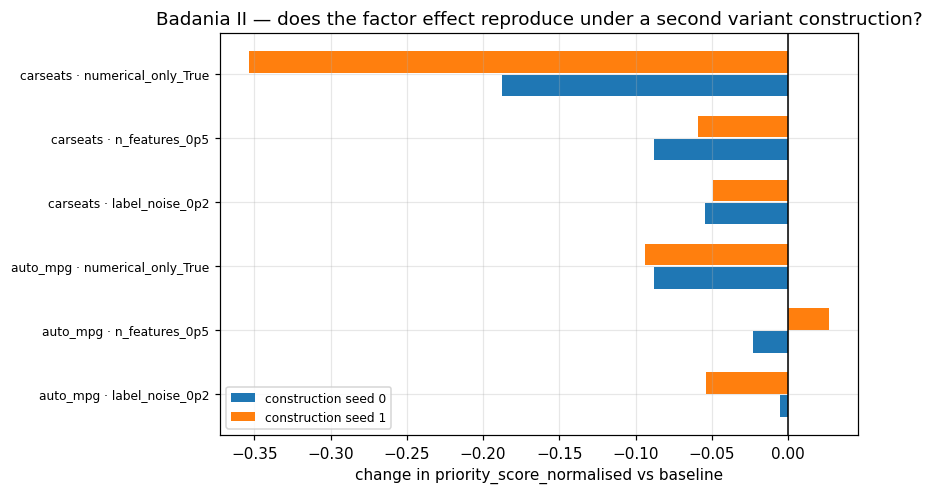

,cell,seed 0,seed 1
0,auto_mpg · label_noise_0p2,-0.0055,-0.0536
1,auto_mpg · n_features_0p5,-0.0231,0.0268
2,auto_mpg · numerical_only_True,-0.0879,-0.0939
3,carseats · label_noise_0p2,-0.0544,-0.0493
4,carseats · n_features_0p5,-0.0877,-0.0593
5,carseats · numerical_only_True,-0.1876,-0.3535


In [10]:
def plot_replication(metric="priority_score_normalised"):
    a = factor_effects("minlp", metric)
    if a.empty:
        print("no data"); return
    a["is_replicate"] = a["level"].eq("s1")
    a["key"] = np.where(a["is_replicate"],
                        a["dataset"] + " · " + a["factor"],
                        a["dataset"] + " · " + a["factor"] + "_" + a["level"])
    pairs = []
    for key, grp in a.groupby("key"):
        if grp["is_replicate"].nunique() == 2:
            pairs.append({"cell": key,
                          "seed 0": float(grp[~grp["is_replicate"]]["delta"].iloc[0]),
                          "seed 1": float(grp[grp["is_replicate"]]["delta"].iloc[0])})
    if not pairs:
        print("no replicated variants found"); return
    rep = pd.DataFrame(pairs)
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(rep) + 1.6))
    y = np.arange(len(rep))
    ax.barh(y - 0.18, rep["seed 0"], height=0.34, label="construction seed 0")
    ax.barh(y + 0.18, rep["seed 1"], height=0.34, label="construction seed 1")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(rep["cell"], fontsize=8)
    ax.set_xlabel(f"change in {metric} vs baseline")
    ax.set_title("Badania II — does the factor effect reproduce under a second variant construction?")
    ax.legend(fontsize=8)
    plt.show()
    display(rep.round(4))

plot_replication()

## 5. Badania III — comparison with established methods

**The question.** How does the method compare with the counterfactual algorithms people actually
use?

**The design.** All methods solve the *identical* instance: same target, same tolerance, same
feasible region (derived from the priority set, so pinned features stay pinned and actionable ones
share the same box), same number of requested counterfactuals. The priority score is computed *post
hoc* for every method, including the seven that do not optimise it — that is the point of the
comparison.

Arms cover four regimes: free budget, a 2 000-evaluation cap, a harder target (−2σ), and releasing
the categorical columns for the baselines.

In [11]:
S3 = "study3_comparison"

def comparison_table(study_name=S3, regime="free budget", valid_only=True):
    df = study(study_name)
    suffix = {"free budget": None, "budget 2 000": "budget2k",
              "harder target (−2σ)": "hard_target", "categorical released": "cat"}[regime]
    if suffix is None:
        df = df[~df["arm"].str.contains("budget2k|hard_target|_cat")]
    else:
        df = df[df["arm"].str.endswith(suffix)]
    if df.empty:
        return pd.DataFrame()
    v = df[df["validity"] == True] if valid_only else df
    out = (df.groupby("arm")
             .agg(n=("sample_id", "size"), validity=("validity", "mean"),
                  model_rows=("model_rows", "mean"), time_s=("time_seconds", "mean"),
                  budget_fail=("error", lambda s: float((s == "budget_exceeded").mean())))
             .join(v.groupby("arm").agg(priority=("priority_score_normalised", "mean"),
                                        l1=("l1", "mean"), n_valid=("sample_id", "size")))
             .reset_index().sort_values("priority", ascending=False))
    return out

def plot_comparison(regime, metric, reference):
    tab = comparison_table(S3, regime)
    if tab.empty:
        print("no arms in this regime"); return
    display(Markdown(f"### {regime}"))
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(tab) + 1.6))
    colours = ["tab:blue" if a.startswith("minlp") else "0.7" for a in tab["arm"]]
    ax.barh(tab["arm"], tab[metric], color=colours)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.set_title(f"Badania III — {regime} (blue = our method)")
    plt.show()
    display(tab.round(3))

    df = study(S3)
    arms = list(tab["arm"])
    if reference in arms:
        v = df[(df["validity"] == True) & (df["arm"].isin(arms))]
        rows = []
        for a in arms:
            if a == reference:
                continue
            r = stats.paired_comparison(v, a, reference, by="arm",
                                        value_col="priority_score_normalised")
            rows.append({"arm": a, "pairs": r.n_pairs, "delta_vs_ref": r.mean_delta,
                         "wins": r.wins_a, "losses": r.wins_b, "wilcoxon_p": r.wilcoxon_p,
                         "cliffs_delta": r.cliffs_delta, "magnitude": r.cliffs_magnitude})
        paired = pd.DataFrame(rows)
        if not paired.empty:
            paired["p_holm"] = stats.holm_correction(list(paired["wilcoxon_p"]))
            display(Markdown(f"**paired against `{reference}`** "
                             "(negative delta = that method is worse)"))
            display(paired.sort_values("delta_vs_ref").round(4))

def _cmp_ui():
    regimes = ["free budget", "budget 2 000", "harder target (−2σ)", "categorical released"]
    reg = widgets.Dropdown(options=regimes, description="regime:")
    met = widgets.Dropdown(options=["priority", "validity", "l1", "model_rows", "budget_fail"],
                           value="priority", description="metric:")
    ref = widgets.Text(value="minlp", description="reference:")
    out = widgets.interactive_output(plot_comparison,
                                     {"regime": reg, "metric": met, "reference": ref})
    display(widgets.VBox([widgets.HBox([reg, met, ref]), out]))

_cmp_ui()

**The results, and the one that matters most.**

*Free budget* — the method reaches 0.923 normalised priority at 96.7 % validity; every baseline lands
between 0.64 and 0.79. Paired, the baselines lose almost every comparison with large effect sizes.

*Budget-matched at 2 000 evaluations* — **the advantage disappears.** The method's validity collapses
from 0.967 to 0.567 (it cannot complete its Shapley + LP + SLSQP pipeline within that budget), and on
the instances where it does finish, the priority-weighted random search is *statistically better*
(+0.035, p = 0.009). Every other method is a statistical tie. **The superiority claim is a statement
about a high-budget regime and must be reported as such.**

*Harder target (−2σ)* — the advantage grows: baselines lose 0 of 78 and 0 of 79 paired comparisons,
Cliff's δ down to −0.90. Preference-aware search matters most where a counterfactual is hard to find.

*Categorical released* — letting the baselines switch categories buys them a little priority
(DiCE +0.028) but destroys their validity (DiCE 1.00 → 0.74, growing spheres 1.00 → 0.13, Wachter
0.57 → 0.10): snapping a one-hot state *after* optimisation moves the prediction out of the band.
Categorical handling has to live inside the search.

Reminder when reading the bars: priority is averaged over **valid** counterfactuals only. A method
that returns the instance unchanged (Nelder–Mead does) scores a high priority and zero validity.

In [12]:
def plot_paired_deltas(arm_a, arm_b, study_name=S3, metric="priority_score_normalised"):
    df = study(study_name)
    v = df[df["validity"] == True]
    merged = stats.paired_frame(v, arm_a, arm_b, value_col=metric, by="arm")
    if merged.empty:
        print("no comparable pairs"); return
    res = stats.paired_comparison(v, arm_a, arm_b, value_col=metric, by="arm")
    d = np.sort(merged["delta"].to_numpy())
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(np.arange(d.size), d, color=["tab:green" if x > 0 else "crimson" for x in d])
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("paired instance (sorted)")
    ax.set_ylabel(f"{arm_a} − {arm_b}")
    ax.set_title(f"{res.wins_a} wins / {res.wins_b} losses · mean Δ = {res.mean_delta:+.3f} · "
                 f"Wilcoxon p = {res.wilcoxon_p:.2e} · Cliff's δ = {res.cliffs_delta:+.2f} "
                 f"({res.cliffs_magnitude})", fontsize=10)
    plt.show()

def _pair_ui():
    df = study(S3)
    arms = sorted(df["arm"].unique())
    a = widgets.Dropdown(options=arms, value="minlp", description="method A:")
    b = widgets.Dropdown(options=arms, value="dice" if "dice" in arms else arms[0],
                         description="method B:")
    out = widgets.interactive_output(plot_paired_deltas, {"arm_a": a, "arm_b": b})
    display(widgets.VBox([widgets.HBox([a, b]), out]))

_pair_ui()

**This is the figure that carries a comparison claim in an article.** Each bar is one instance
solved by both methods; green means A won. Method-level averages hide the fact that methods succeed
on different subsets of instances, which is why every statistical statement in this project is
paired.

## 6. Exporting figures for the article

Every plotting function above ends with `plt.show()`. To export, call it inside the helper below —
it captures the current figure and writes a 200 dpi PNG into `paper/figures/`.

In [ ]:
def export(plot_call, name):
    """Run a plotting call and save whatever figure it produced."""
    plot_call()
    fig = plt.gcf()
    return save_fig(fig, name)

# Examples — uncomment what you need:
# export(lambda: plot_priority_feature("auto_mpg", "medium", 1, "weight", True, False),
#        "priority_curve_auto_mpg_weight")
# export(lambda: plot_budget_pareto("study3_comparison", True, True), "cost_vs_quality")
# export(lambda: plot_factor_forest("minlp", "priority_score_normalised", True, 0.05),
#        "factor_effects_minlp")
# export(lambda: plot_paired_deltas("minlp", "dice"), "paired_minlp_vs_dice")
print("figures directory:", FIGURES_DIR)

## 7. Extending this notebook

The notebook is deliberately generic; adding new material should not require editing the plotting
code.

**A new metric.** Any column present in a study's `counterfactuals.csv` appears automatically in the
metric dropdowns — add the column in `paper/common/execute.py`, re-run the study, and it shows up.

**A new dataset.** Prepare it (`data_setup.py`), train a model (`model_setup.py`), add a scenario
spec to `priority_sets.py`. It then appears in every dataset dropdown here, and can be listed in any
study config.

**A new priority set.** Add it under `PRIORITY_SETS[dataset]`; the priority widgets pick it up with
no further change. Check it with `priority_sets_check.py` before running a study.

**A new study.** Create `paper/<study_name>/config.yaml` and run
`python -m explainit.experiments.paper.run_study --config …`. It appears in the state table, the
study dropdowns and the cost-vs-quality plot automatically.

**A new method.** Register it in the priority-methods registry or the standard-methods registry; the
bridge exposes both under one name space, so a study config can simply name it.

**Useful commands**

```bash
python -m explainit.experiments.paper.status                         # what is running / complete
python -m explainit.experiments.paper.run_study --config <cfg>       # run or resume a study
python -m explainit.experiments.paper.analyse_study --study <name> --by arm --reference minlp
python -m explainit.experiments.paper.analyse_factors --study study2_factors --method minlp
python -m explainit.experiments.continuous_minlp.priority_sets_check --datasets <ds>
```

The narrative write-up of the design and all findings lives in `EXPERIMENTS.md` next to this
notebook.